# Probability and Data Distributions

## Key Probability Concepts

### Random Variables and Distributions

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add project root to path
sys.path.insert(0, str(Path().resolve().parent))

from config import DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ── Load the processed dataset from Chapter 3 ─────────────────────────────
df = pd.read_csv(DATA_PROCESSED / "housing_processed.csv")
print(f"Loaded housing_processed.csv: {df.shape[0]} rows, {df.shape[1]} columns")

# ── salePrice is already log-transformed in housing_processed.csv ─────────
# Use it directly; back-transform for price-scale examples
log_sale_price = df["salePrice"]
sale_price_raw = np.expm1(log_sale_price)   # original USD scale

print(f"\nlog(salePrice) — mean: {log_sale_price.mean():.4f}, "
      f"std: {log_sale_price.std():.4f}")
print(f"salePrice (USD) — mean: {sale_price_raw.mean():,.0f}, "
      f"median: {sale_price_raw.median():,.0f}")

Loaded housing_processed.csv: 2927 rows, 224 columns

log(salePrice) — mean: 12.0209, std: 0.4078
salePrice (USD) — mean: 180,801, median: 160,000


In [2]:
# CDF in practice: P(X <= 900) for Normal(1000, 200)
dist_demo = stats.norm(loc=1000, scale=200)
prob_demo = dist_demo.cdf(900)
print(f"P(sales <= 900) = {prob_demo:.4f}")   # 0.3085

# Inverse CDF (quantile function): 95th percentile
p95_demo = dist_demo.ppf(0.95)
print(f"95th percentile  = {p95_demo:.1f}")   # 1329.0

# ── Same operations on the real log-SalePrice distribution ─────────────────
mu_log, sigma_log = log_sale_price.mean(), log_sale_price.std()
dist_real = stats.norm(loc=mu_log, scale=sigma_log)

# P(log(salePrice) <= log(200_000))
threshold_log = np.log1p(200_000)
prob_real = dist_real.cdf(threshold_log)
print(f"\nReal data — P(salePrice ≤ $200,000) ≈ {prob_real:.4f}")

# 95th percentile in original USD
p95_real = np.expm1(dist_real.ppf(0.95))
print(f"Real data — 95th percentile (USD) ≈ ${p95_real:,.0f}")

P(sales <= 900) = 0.3085
95th percentile  = 1329.0

Real data — P(salePrice ≤ $200,000) ≈ 0.6751
Real data — 95th percentile (USD) ≈ $325,025


### Expectation and Variance

In [3]:
rng = np.random.default_rng(RANDOM_SEED)
samples = rng.normal(loc=1000, scale=200, size=10_000)

print(f"Sample mean:  {samples.mean():.2f}")   # ≈ 1000
print(f"Sample std:   {samples.std():.2f}")    # ≈ 200
print(f"Sample var:   {samples.var():.2f}")    # ≈ 40000

Sample mean:  997.95
Sample std:   201.26
Sample var:   40504.44


### Independence and Correlation

In [4]:
# Correlated vs. independent samples
rng = np.random.default_rng(0)
n = 500

# Independent
x = rng.normal(size=n)
y_indep = rng.normal(size=n)

# Correlated (ρ ≈ 0.8)
y_corr = 0.8 * x + np.sqrt(1 - 0.8**2) * rng.normal(size=n)

print(f"Independent: ρ = {np.corrcoef(x, y_indep)[0,1]:.3f}")   # ≈ 0
print(f"Correlated:  ρ = {np.corrcoef(x, y_corr)[0,1]:.3f}")    # ≈ 0.8

Independent: ρ = 0.005
Correlated:  ρ = 0.806


## Common Distributions

### The Normal Distribution

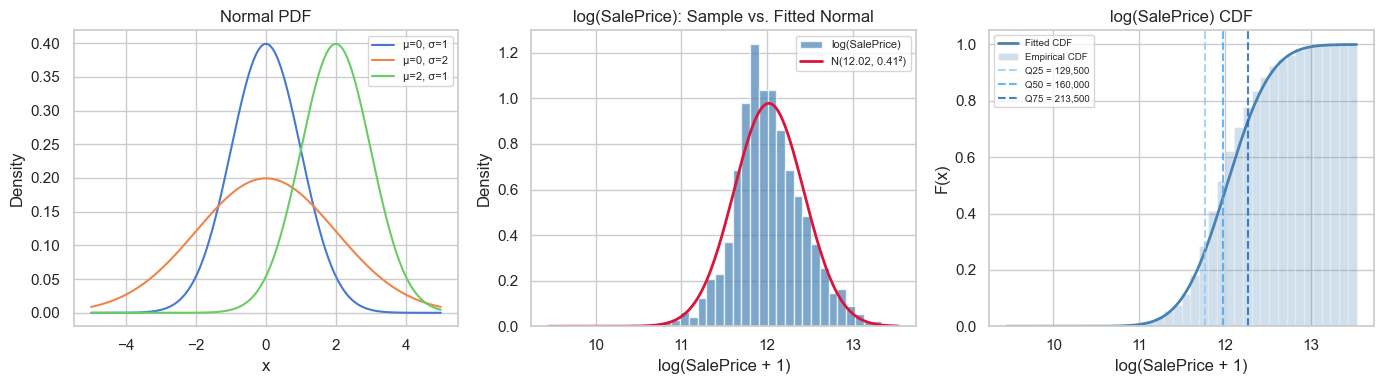

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: PDF for different parameters ---
x = np.linspace(-5, 5, 300)
for mu, sigma, label in [(0, 1, "μ=0, σ=1"),
                          (0, 2, "μ=0, σ=2"),
                          (2, 1, "μ=2, σ=1")]:
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma), label=label)
axes[0].set_title("Normal PDF")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# --- Panel 2: Real log(SalePrice) vs. fitted Normal ---
axes[1].hist(log_sale_price, bins=40, density=True, color="steelblue",
             edgecolor="white", alpha=0.7, label="log(SalePrice)")
x_fit = np.linspace(log_sale_price.min(), log_sale_price.max(), 300)
axes[1].plot(x_fit,
             stats.norm.pdf(x_fit, mu_log, sigma_log),
             "crimson", lw=2, label=f"N({mu_log:.2f}, {sigma_log:.2f}²)")
axes[1].set_title("log(SalePrice): Sample vs. Fitted Normal")
axes[1].set_xlabel("log(SalePrice + 1)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

# --- Panel 3: CDF with quartile markers ---
x_cdf = np.linspace(log_sale_price.min(), log_sale_price.max(), 300)
axes[2].plot(x_cdf, stats.norm.cdf(x_cdf, mu_log, sigma_log),
             color="steelblue", lw=2, label="Fitted CDF")
axes[2].hist(log_sale_price, bins=40, density=True, cumulative=True,
             color="steelblue", edgecolor="white", alpha=0.25,
             label="Empirical CDF")
for q, color in [(0.25, "#90CAF9"), (0.50, "#42A5F5"), (0.75, "#1565C0")]:
    val = np.quantile(log_sale_price, q)
    axes[2].axvline(val, color=color, linestyle="--", alpha=0.8,
                    label=f"Q{int(q*100)} = {np.expm1(val):,.0f}")
axes[2].set_title("log(SalePrice) CDF")
axes[2].set_xlabel("log(SalePrice + 1)")
axes[2].set_ylabel("F(x)")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES / "ch04_normal.png", dpi=150, bbox_inches="tight")
plt.show()

#### Standardization and the Standard Normal

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X_raw = np.array([[1000, 0.5],
                  [1200, 0.8],
                  [ 800, 0.3]])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(X_scaled.mean(axis=0).round(10))  # [0. 0.]
print(X_scaled.std(axis=0).round(10))   # [1. 1.]

[0. 0.]
[1. 1.]


### The Binomial Distribution

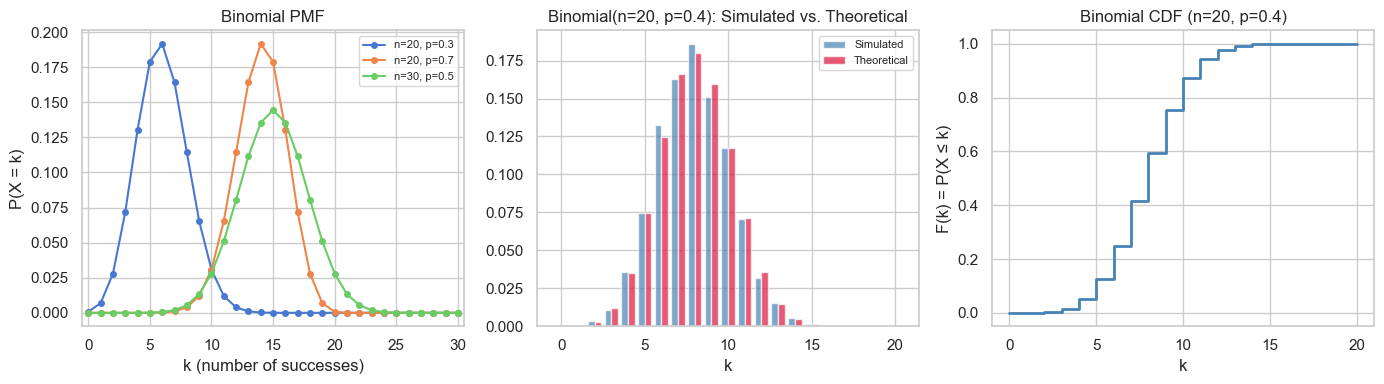

In [7]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: PMF for different parameters ---
k = np.arange(0, 31)
for n, p, label in [(20, 0.3, "n=20, p=0.3"),
                    (20, 0.7, "n=20, p=0.7"),
                    (30, 0.5, "n=30, p=0.5")]:
    axes[0].plot(k, stats.binom.pmf(k, n, p), "o-", ms=4, label=label)
axes[0].set_title("Binomial PMF")
axes[0].set_xlabel("k (number of successes)")
axes[0].set_ylabel("P(X = k)")
axes[0].legend(fontsize=8)
axes[0].set_xlim(-0.5, 30.5)

# --- Panel 2: Empirical frequencies vs. PMF ---
n, p = 20, 0.4
samples = rng.binomial(n=n, p=p, size=5000)
k_range = np.arange(0, n + 1)
axes[1].bar(k_range - 0.2, np.bincount(samples, minlength=n+1) / 5000,
            width=0.4, color="steelblue", alpha=0.7, label="Simulated")
axes[1].bar(k_range + 0.2, stats.binom.pmf(k_range, n, p),
            width=0.4, color="crimson", alpha=0.7, label="Theoretical")
axes[1].set_title(f"Binomial(n={n}, p={p}): Simulated vs. Theoretical")
axes[1].set_xlabel("k")
axes[1].legend(fontsize=8)

# --- Panel 3: CDF ---
axes[2].step(k_range, stats.binom.cdf(k_range, n, p),
             color="steelblue", where="post", lw=2)
axes[2].set_title(f"Binomial CDF (n={n}, p={p})")
axes[2].set_xlabel("k")
axes[2].set_ylabel("F(k) = P(X ≤ k)")

plt.tight_layout()
plt.savefig(FIGURES / "ch04_binomial.png", dpi=150, bbox_inches="tight")
plt.show()

#### Practical Example: Conversion Rate Testing

#### Use statsmodels (Recommended)

In [8]:
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

n, k = 1000, 87

# P(X >= 87 | p = 0.10)
p_value = 1 - stats.binom.cdf(k - 1, n, 0.10)
print(f"p-value: {p_value:.4f}")

# 95% Wilson confidence interval
ci = proportion_confint(k, n, alpha=0.05, method="wilson")
print(f"95% CI for p: ({ci[0]:.4f}, {ci[1]:.4f})")

p-value: 0.9249
95% CI for p: (0.0711, 0.1061)


#### Pure SciPy (No extra dependency)

In [9]:
from scipy import stats

n, k = 1000, 87

# Binomial test (same as before)
p_value = 1 - stats.binom.cdf(k - 1, n, 0.10)
print(f"p-value: {p_value:.4f}")

# Confidence interval
res = stats.binomtest(k, n)
ci = res.proportion_ci(confidence_level=0.95, method="wilson")

print(f"95% CI for p: ({ci.low:.4f}, {ci.high:.4f})")

p-value: 0.9249
95% CI for p: (0.0711, 0.1061)


### The Poisson Distribution

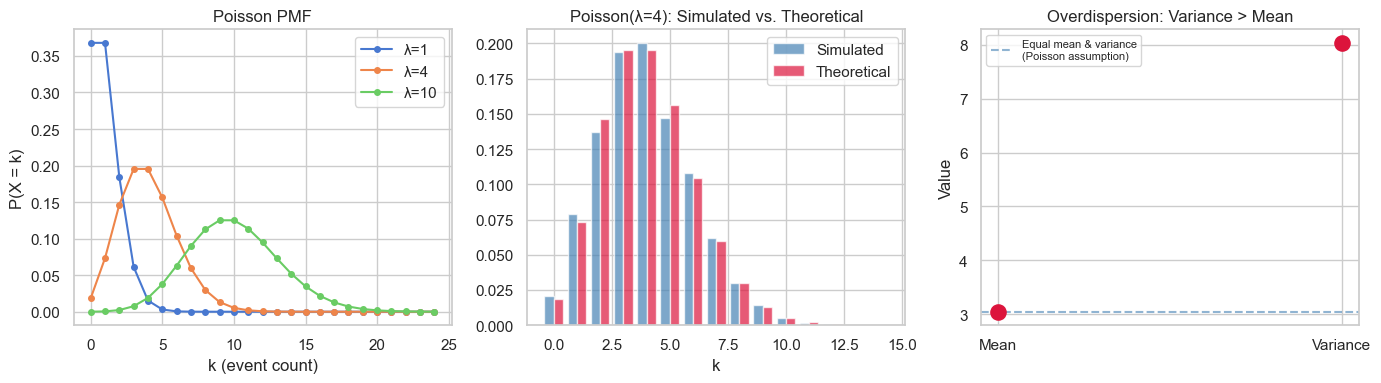

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: PMF for different λ ---
k = np.arange(0, 25)
for lam, label in [(1, "λ=1"), (4, "λ=4"), (10, "λ=10")]:
    axes[0].plot(k, stats.poisson.pmf(k, lam), "o-", ms=4, label=label)
axes[0].set_title("Poisson PMF")
axes[0].set_xlabel("k (event count)")
axes[0].set_ylabel("P(X = k)")
axes[0].legend()

# --- Panel 2: Simulated vs. theoretical for λ=4 ---
lam = 4
samples = rng.poisson(lam=lam, size=5000)
k_range = np.arange(0, 15)
axes[1].bar(k_range - 0.2, np.bincount(samples, minlength=15) / 5000,
            width=0.4, color="steelblue", alpha=0.7, label="Simulated")
axes[1].bar(k_range + 0.2, stats.poisson.pmf(k_range, lam),
            width=0.4, color="crimson", alpha=0.7, label="Theoretical")
axes[1].set_title(f"Poisson(λ={lam}): Simulated vs. Theoretical")
axes[1].set_xlabel("k")
axes[1].legend()

# --- Panel 3: Overdispersion check ---
counts = rng.negative_binomial(n=2, p=0.4, size=2000)  # overdispersed counts
axes[2].scatter(["Mean", "Variance"],
                [counts.mean(), counts.var()],
                s=120, color="crimson", zorder=5)
axes[2].axhline(counts.mean(), color="steelblue", linestyle="--", alpha=0.6,
                label="Equal mean & variance\n(Poisson assumption)")
axes[2].set_title("Overdispersion: Variance > Mean")
axes[2].set_ylabel("Value")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch04_poisson.png", dpi=150, bbox_inches="tight")
plt.show()

## Beyond the Big Three: Other Distributions in Modeling

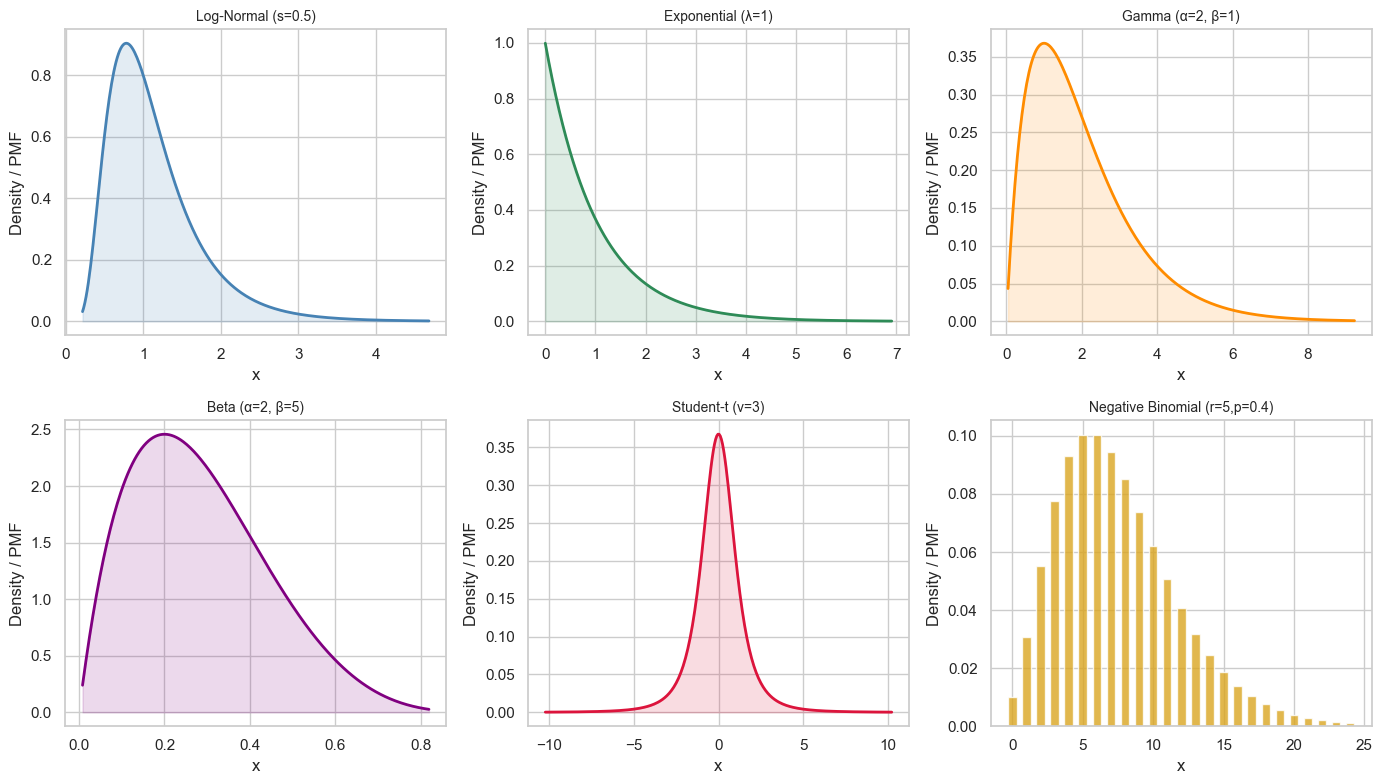

In [11]:
# Quick visual survey of continuous distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

configs = [
    (stats.lognorm(s=0.5),          "Log-Normal (s=0.5)",          "steelblue"),
    (stats.expon(scale=1.0),        "Exponential (λ=1)",           "seagreen"),
    (stats.gamma(a=2, scale=1.0),   "Gamma (α=2, β=1)",            "darkorange"),
    (stats.beta(a=2, b=5),          "Beta (α=2, β=5)",             "purple"),
    (stats.t(df=3),                 "Student-t (ν=3)",             "crimson"),
    (stats.nbinom(n=5, p=0.4),      "Negative Binomial (r=5,p=0.4)","goldenrod"),
]

for ax, (dist_obj, title, color) in zip(axes, configs):

    # ✅ Detect discrete vs continuous via available methods
    if hasattr(dist_obj, "pmf"):   # discrete
        k = np.arange(0, 25)
        ax.bar(k, dist_obj.pmf(k), color=color, alpha=0.8, width=0.6)

    else:  # continuous
        x_range = np.linspace(*dist_obj.ppf([0.001, 0.999]), 300)
        y = dist_obj.pdf(x_range)
        ax.plot(x_range, y, color=color, lw=2)
        ax.fill_between(x_range, y, alpha=0.15, color=color)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("Density / PMF")

plt.tight_layout()
plt.savefig(FIGURES / "ch04_distribution_gallery.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Sampling and Simulation

### The Central Limit Theorem

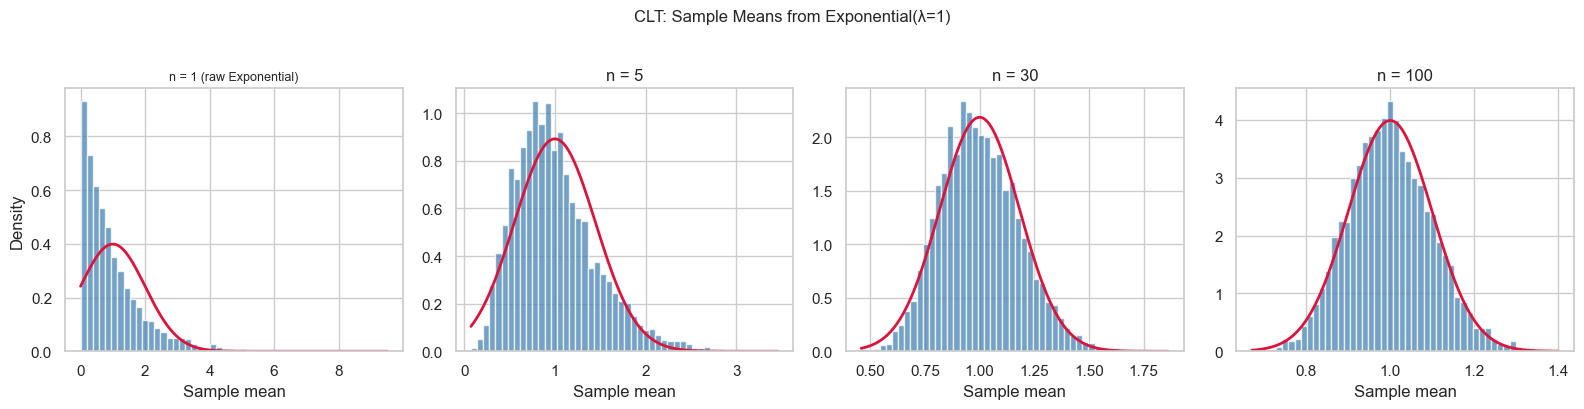

In [12]:
# Visualising the CLT: sample means from a right-skewed Exponential distribution
rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_sizes = [1, 5, 30, 100]
lam = 1.0  # Exponential rate: mean = 1/λ = 1, std = 1/λ = 1

for ax, n in zip(axes, sample_sizes):
    # Draw 5000 sample means, each computed from n Exponential observations
    means = rng.exponential(scale=1/lam, size=(5000, n)).mean(axis=1)
    ax.hist(means, bins=50, density=True, color="steelblue",
            edgecolor="white", alpha=0.75)

    # Theoretical CLT Normal overlay
    mu_clt    = 1 / lam
    sigma_clt = (1 / lam) / np.sqrt(n)
    x_range   = np.linspace(means.min(), means.max(), 200)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_clt, sigma_clt),
            "crimson", lw=2)

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density" if n == 1 else "")

axes[0].set_title("n = 1 (raw Exponential)", fontsize=9)
plt.suptitle("CLT: Sample Means from Exponential(λ=1)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "ch04_clt.png", dpi=150, bbox_inches="tight")
plt.show()

### Monte Carlo Simulation

#### Estimating π by Simulation

In [13]:
rng = np.random.default_rng(RANDOM_SEED)
n = 1_000_000

x = rng.uniform(0, 1, n)
y = rng.uniform(0, 1, n)
inside = (x**2 + y**2) <= 1.0

pi_estimate = 4 * inside.mean()
print(f"π estimate (n={n:,}): {pi_estimate:.6f}")   # ≈ 3.141592
print(f"True π:              {np.pi:.6f}")

π estimate (n=1,000,000): 3.142436
True π:              3.141593


#### Propagating Uncertainty Through a Model

In [14]:
rng = np.random.default_rng(RANDOM_SEED)
n_simulations = 100_000

# Coefficient uncertainty from a Ridge model fitted on housing data
# (approximate posterior: β₀ ≈ 12.02, β₁ ≈ 0.50 for log(grLivArea) → log(salePrice))
beta_0 = rng.normal(loc=12.02, scale=0.05, size=n_simulations)
beta_1 = rng.normal(loc=0.50,  scale=0.02, size=n_simulations)

# Input uncertainty: log(grLivArea) measured with noise (σ ≈ 0.02 log-units)
x_true  = np.log1p(1500)          # a 1,500 sq ft home
x_noisy = rng.normal(loc=x_true, scale=0.02, size=n_simulations)

# Prediction distribution (log-price scale)
y_pred_log = beta_0 + beta_1 * x_noisy

# Convert back to USD for interpretability
y_pred_usd = np.expm1(y_pred_log)

print(f"Predicted log(price) — mean:  {y_pred_log.mean():.4f}")
print(f"Predicted log(price) — std:   {y_pred_log.std():.4f}")
print(f"Predicted price (USD) — mean: ${y_pred_usd.mean():,.0f}")
print(f"90% prediction interval (USD): "
      f"(${np.percentile(y_pred_usd, 5):,.0f}, "
      f"${np.percentile(y_pred_usd, 95):,.0f})")

Predicted log(price) — mean:  15.6771
Predicted log(price) — std:   0.1552
Predicted price (USD) — mean: $6,512,300
90% prediction interval (USD): ($4,983,927, $8,309,147)


#### Simulating Synthetic Datasets for Model Validation

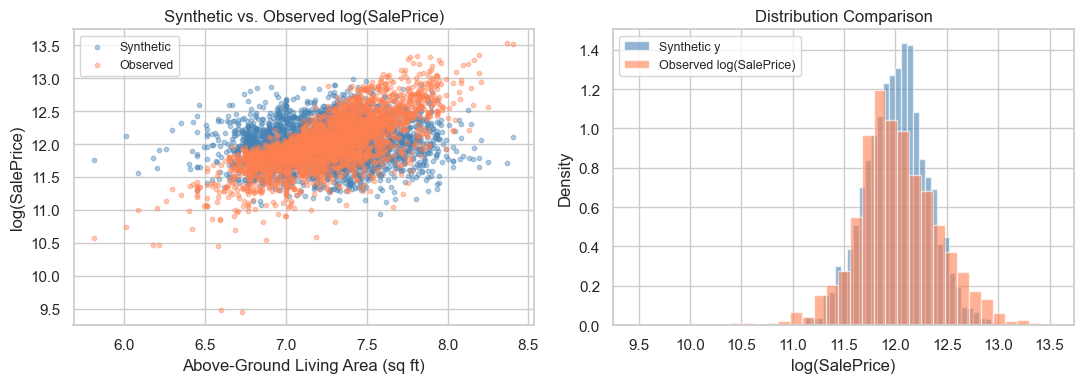

In [16]:
import pandas as pd
import numpy as np

rng = np.random.default_rng(RANDOM_SEED)
n = len(df)

# ── Load a meaningful predictor from the standardized dataset ─────────────
# housing_stand_name.csv has camelCase column names (produced in Chapter 3)
df_stand = pd.read_csv(DATA_PROCESSED / "housing_ols_ready.csv")
# Use grLivArea (above-ground living area) as the predictor x
x_real = df_stand["grLivArea"].dropna().values[:n]

# Assumed data-generating process: linear regression with Normal errors
# Coefficients estimated from the processed data for illustration
true_beta_0 = log_sale_price.mean() - 0.5 * np.log1p(x_real).mean()
true_beta_1 = 0.5
true_sigma  = 0.3

x_log = np.log1p(x_real)
y_synthetic = true_beta_0 + true_beta_1 * x_log + rng.normal(0, true_sigma, n)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(x_real, y_synthetic, s=10, alpha=0.4, color="steelblue",
                label="Synthetic")
axes[0].scatter(x_real, log_sale_price.values[:n], s=10, alpha=0.4,
                color="coral", label="Observed")
axes[0].set_title("Synthetic vs. Observed log(SalePrice)")
axes[0].set_xlabel("Above-Ground Living Area (sq ft)")
axes[0].set_ylabel("log(SalePrice)")
axes[0].legend(fontsize=9)

axes[1].hist(y_synthetic, bins=35, color="steelblue", edgecolor="white",
             density=True, alpha=0.6, label="Synthetic y")
axes[1].hist(log_sale_price, bins=35, color="coral", edgecolor="white",
             density=True, alpha=0.6, label="Observed log(SalePrice)")
axes[1].set_title("Distribution Comparison")
axes[1].set_xlabel("log(SalePrice)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "ch04_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()

### Sampling from Empirical Distributions

In [17]:
# Use actual sale prices (USD) from the processed dataset
observed_sales = sale_price_raw.values

# Bootstrap confidence interval for the median sale price
n_boot = 10_000
boot_medians = np.array([
    np.median(rng.choice(observed_sales, size=len(observed_sales),
                         replace=True))
    for _ in range(n_boot)
])

ci_lower, ci_upper = np.percentile(boot_medians, [2.5, 97.5])
print(f"Sample median:      ${np.median(observed_sales):,.0f}")
print(f"Bootstrap 95% CI:   (${ci_lower:,.0f}, ${ci_upper:,.0f})")

Sample median:      $160,000
Bootstrap 95% CI:   ($158,000, $164,500)


### Fitting Distributions to Data

In [19]:
# Fit distributions to real sale prices (USD) — positive, right-skewed
data = sale_price_raw.values

# Fit a Log-Normal distribution
shape, loc, scale = stats.lognorm.fit(data, floc=0)  # fix loc=0 for positive data
print(f"Fitted Log-Normal: σ={shape:.3f}, μ=ln(scale)={np.log(scale):.3f}")

# Compare candidate distributions with the Kolmogorov-Smirnov test
for dist_name in ["norm", "lognorm", "expon", "gamma"]:
    dist_obj = getattr(stats, dist_name)
    params = dist_obj.fit(data, floc=0) if dist_name != "norm" else dist_obj.fit(data)
    ks_stat, ks_p = stats.kstest(data, dist_name, args=params)
    print(f"{dist_name:10s}  KS statistic={ks_stat:.4f}, p={ks_p:.4f}")

Fitted Log-Normal: σ=0.408, μ=ln(scale)=12.021
norm        KS statistic=0.1231, p=0.0000
lognorm     KS statistic=0.0413, p=0.0001
expon       KS statistic=0.3456, p=0.0000
gamma       KS statistic=0.0670, p=0.0000


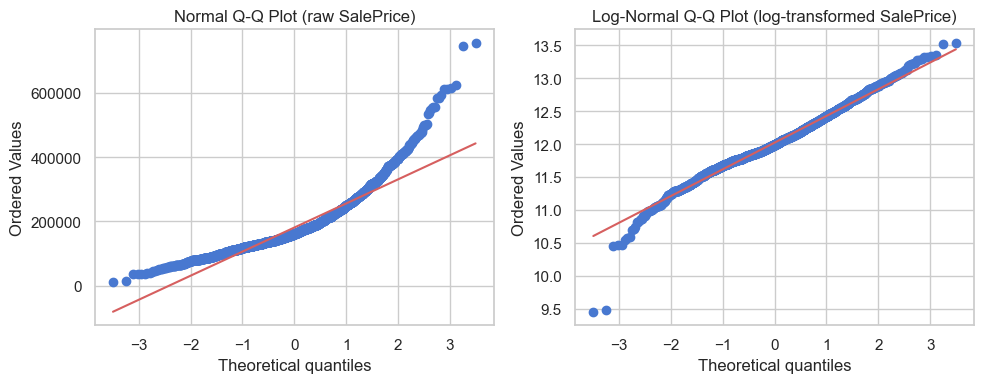

In [20]:
# Q-Q plot: compare sample quantiles to Log-Normal theoretical quantiles
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Normal Q-Q (should show heavy right tail for raw prices)
stats.probplot(data, dist="norm", plot=axes[0])
axes[0].set_title("Normal Q-Q Plot (raw SalePrice)")

# Log-Normal Q-Q (log-transformed prices should be straight line)
stats.probplot(np.log(data), dist="norm", plot=axes[1])
axes[1].set_title("Log-Normal Q-Q Plot (log-transformed SalePrice)")

plt.tight_layout()
plt.savefig(FIGURES / "ch04_qqplot.png", dpi=150, bbox_inches="tight")
plt.show()